Step 3: Logistic regression

Rain or no rain?

In [47]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve, classification_report, 
                            confusion_matrix, roc_auc_score, 
                            precision_recall_curve, auc, f1_score)
import shap
import matplotlib.pyplot as plt


Read data

In [48]:
file = 'hourly_columbia_weather.parquet'

# Read parquet into dataframe
df = pd.read_parquet(file)

print(df.head())

                     temp  dwpt  rhum  prcp   wdir  wspd    pres  coco  \
2024-01-02 00:00:00  10.0   1.1  54.0   0.0   20.0  14.8  1019.2   3.0   
2024-01-02 01:00:00   8.9  -2.1  46.0   0.0  350.0  13.0  1020.2   3.0   
2024-01-02 02:00:00   6.7  -3.8  47.0   0.0    2.0   7.0  1021.2   3.0   
2024-01-02 03:00:00   6.1  -3.8  49.0   0.0  350.0   7.6  1022.2   2.0   
2024-01-02 04:00:00   5.6  -4.3  49.0   0.0  350.0   7.6  1022.8   3.0   

                     prcp_flag       day_sin  ...  wspd_roll12  prcp_roll3  \
2024-01-02 00:00:00          0 -9.634256e-12  ...     9.116667         0.0   
2024-01-02 01:00:00          0  2.588190e-01  ...     9.900000         0.0   
2024-01-02 02:00:00          0  5.000000e-01  ...    10.533333         0.0   
2024-01-02 03:00:00          0  7.071068e-01  ...    11.116667         0.0   
2024-01-02 04:00:00          0  8.660254e-01  ...    10.816667         0.0   

                     prcp_roll6  prcp_roll12  dwpt_roll3  dwpt_roll6  \
2024-01-02 00:

In [49]:
print(df.columns)

Index(['temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'coco',
       'prcp_flag', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
       'year_cos', 'wdir_sin', 'wdir_cos', 'temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24', 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6', 'temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12'],
      dtype='object')


Prepare data, split into x and y

In [50]:
# defining target (Y) and explanatory variables (X)
exclude_reg = ['wdir', 'coco', 'prcp', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6']
exclude_time = exclude_reg + ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
       'year_cos']
exclude_lag = exclude_reg + ['temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24', 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6']
exclude_roll = exclude_reg + ['temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12']
exclude_alot = exclude_lag + exclude_time + ['dwpt', 'rhum', 'pres']

target_name = 'prcp_flag'
###
# edit exclusion
###
exclude = exclude_reg + [target_name]
X = df.drop(columns=exclude)
Y = df[target_name]
# standardize X (not Y)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

print(X)
print(X_scaled)
print(Y)

                     temp  dwpt  rhum  wspd    pres       day_sin   day_cos  \
2024-01-02 00:00:00  10.0   1.1  54.0  14.8  1019.2 -9.634256e-12  1.000000   
2024-01-02 01:00:00   8.9  -2.1  46.0  13.0  1020.2  2.588190e-01  0.965926   
2024-01-02 02:00:00   6.7  -3.8  47.0   7.0  1021.2  5.000000e-01  0.866025   
2024-01-02 03:00:00   6.1  -3.8  49.0   7.6  1022.2  7.071068e-01  0.707107   
2024-01-02 04:00:00   5.6  -4.3  49.0   7.6  1022.8  8.660254e-01  0.500000   
...                   ...   ...   ...   ...     ...           ...       ...   
2024-12-31 20:00:00  21.7  12.8  57.0  20.5  1004.7 -8.660254e-01  0.500000   
2024-12-31 21:00:00  22.2  11.6  51.0  16.6  1004.5 -7.071068e-01  0.707107   
2024-12-31 22:00:00  21.1  10.0  49.0  20.5  1004.9 -5.000000e-01  0.866025   
2024-12-31 23:00:00  18.9  10.7  59.0  11.2  1005.2 -2.588190e-01  0.965926   
2025-01-01 00:00:00  18.0  11.3  65.0  15.0  1006.0 -1.227450e-11  1.000000   

                     week_sin  week_cos  year_sin  

Train/test split

In [51]:
# train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42)

# fitting a RF model
model = LogisticRegression(class_weight="balanced")
#model = LogisticRegression(class_weight={0: 1, 1: 4})
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

c:\Users\Student Account\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Choose threshold (minimum probability to predict rain)

In [52]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)

# Compute F1 score for each threshold
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall:    {recall[best_idx]:.3f}")
print(f"F1-score:  {f1[best_idx]:.3f}")

Best threshold: 0.869
Precision: 0.675
Recall:    0.714
F1-score:  0.694


Use threshold to adjust predictions

In [53]:
threshold = 0.869
y_pred = (y_prob >= threshold).astype(int)


Evaluation

In [54]:
print(classification_report(Y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.978     0.975     0.976      1634
           1      0.669     0.697     0.683       119

    accuracy                          0.956      1753
   macro avg      0.824     0.836     0.830      1753
weighted avg      0.957     0.956     0.956      1753



In [55]:
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[1593   41]
 [  36   83]]


In [56]:
roc = roc_auc_score(Y_test, y_prob)
print("ROC-AUC:", roc)

ROC-AUC: 0.9658259876778128


In [57]:
precision, recall, _ = precision_recall_curve(Y_test, y_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

PR-AUC: 0.7343676569545837


SHAP

c:\Users\Student Account\anaconda3\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


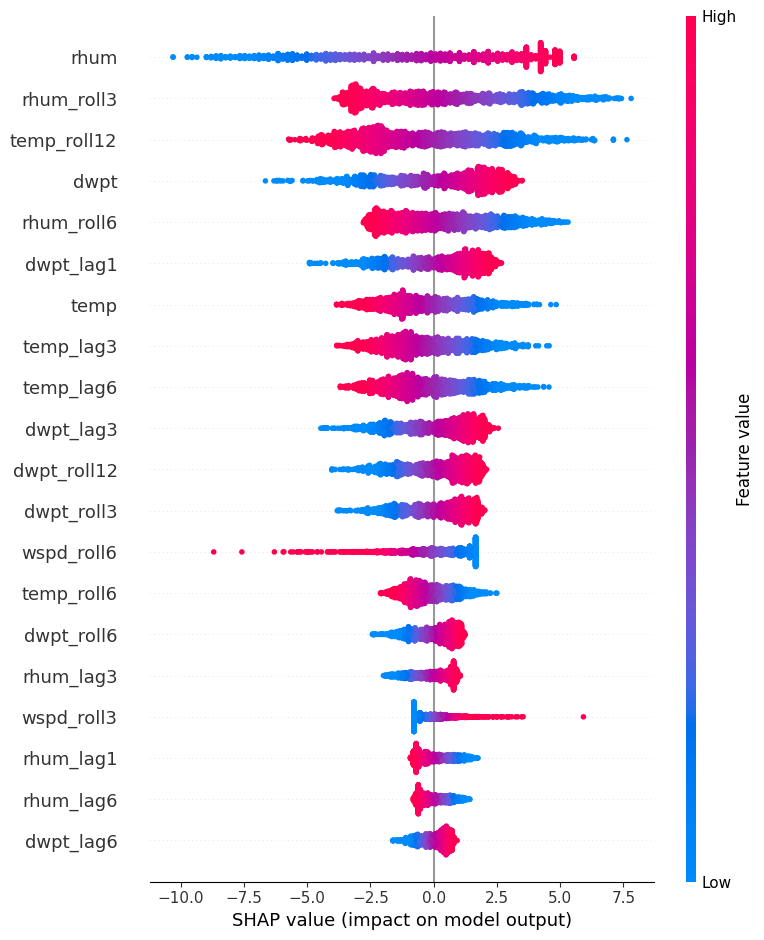

In [60]:
explainer = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

shap_values_proba = explainer.expected_value + shap_values
probs = 1 / (1 + np.exp(-shap_values_proba))  # Convert log-odds to probabilities

# shap_values[0] for class 0, shap_values[1] for class 1
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())  # Class 1 (e.g., rain)